# 04 · Macro-Grid Signal Analysis

Analyses the `MacroGridSignal` module: AR(1) RegD frequency regulation signal, NYISO NYC zone load profile, and LMP proxy.

In [1]:
import sys, os
os.chdir("/lustre/guillant/C2G-Macro")
sys.path.insert(0, ".")
import numpy as np, matplotlib.pyplot as plt
from scipy import signal as sp_signal
from c2g_env.simulators.macro_grid import MacroGridSignal

gs = MacroGridSignal(energy_dir="data/processed/energy", zone="NYC",
                     dt_seconds=300, committed_mw=20.0, seed=42)
print(f"Horizon ticks : {gs.horizon_ticks:,}  ({gs.horizon_ticks*300/3600:.0f} h)")
lmp_s = gs.lmp_stats
print(f"LMP  mean={lmp_s['mean']:.1f}  p95={lmp_s['p95']:.1f}  max={lmp_s['max']:.1f}  $/MWh")

Horizon ticks : 107,260  (8938 h)


LMP  mean=36.4  p95=69.6  max=118.4  $/MWh


## 4.1 Full NYISO NYC Load Profile

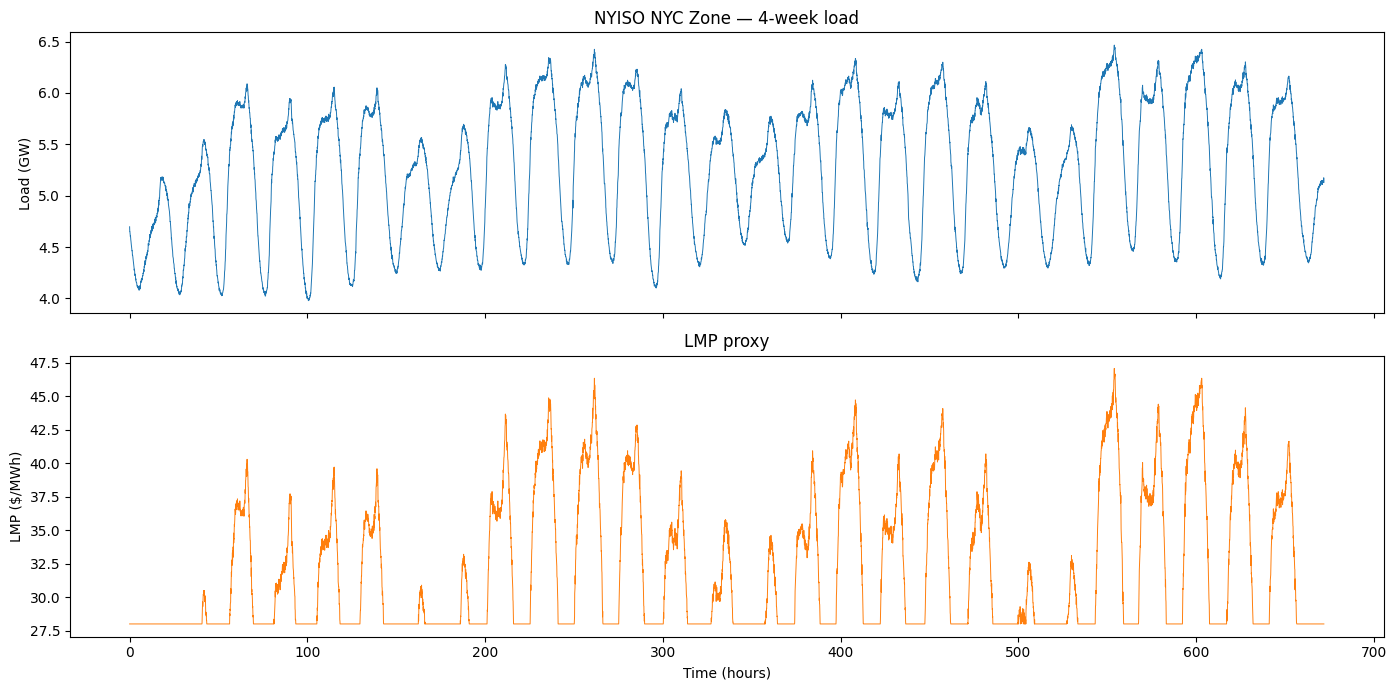

In [2]:
# Collect 4 weeks (~ 8064 ticks)
N_PLOT = 8064
steps = []
gs.reset(seed=0)
for _ in range(N_PLOT):
    steps.append(gs.step())

t_h = np.arange(N_PLOT) * 300 / 3600
load  = np.array([s["grid_load_mw"]  for s in steps])
ln    = np.array([s["load_norm"]     for s in steps])
lmps  = np.array([s["lmp_usd_mwh"]  for s in steps])

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
axes[0].plot(t_h, load / 1e3, lw=0.7)
axes[0].set_ylabel("Load (GW)"); axes[0].set_title("NYISO NYC Zone — 4-week load")

axes[1].plot(t_h, lmps, lw=0.7, color="tab:orange")
axes[1].set_ylabel("LMP ($/MWh)"); axes[1].set_xlabel("Time (hours)")
axes[1].set_title("LMP proxy")
plt.tight_layout(); plt.savefig("notebooks/fig_grid_profile.png", dpi=120); plt.show()

## 4.2 LMP Distribution and Diurnal Pattern

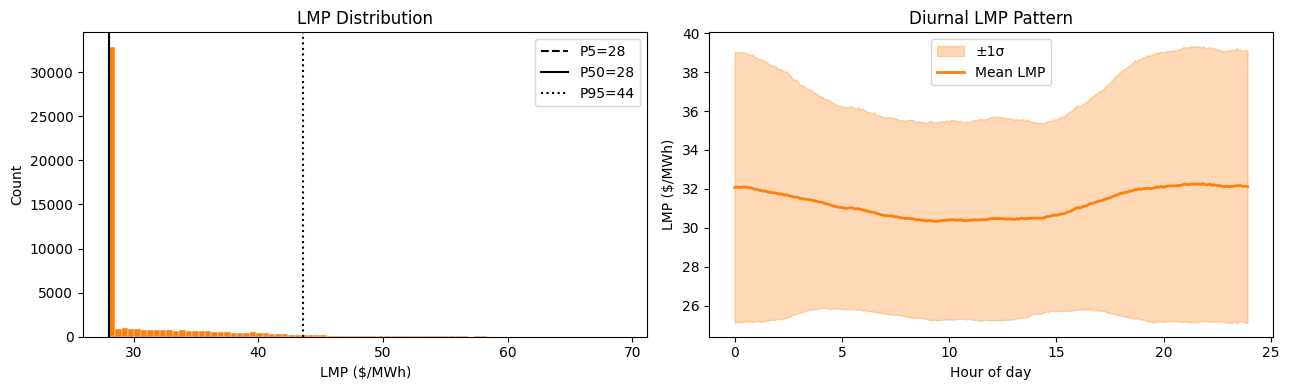

In [3]:
# Full horizon LMP
gs_full = MacroGridSignal("data/processed/energy", zone="NYC", dt_seconds=300, committed_mw=20.0, seed=0)
lmps_full, load_full = [], []
gs_full.reset()
for _ in range(min(gs_full.horizon_ticks, 52560)):   # 1 year max
    s = gs_full.step()
    lmps_full.append(s["lmp_usd_mwh"])
    load_full.append(s["grid_load_mw"])
lmps_full = np.array(lmps_full)

# Diurnal: tick mod 288 = time-of-day
tod = np.arange(min(len(lmps_full), 52560)) % 288   # ticks per day
tod_mean = [lmps_full[tod == h].mean() for h in range(288)]
tod_std  = [lmps_full[tod == h].std()  for h in range(288)]
t_daily = np.arange(288) * 5 / 60   # hours

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(lmps_full, bins=80, color="tab:orange", edgecolor="white",lw=0.3)
for p, ls in [(5,"--"),(50,"-"),(95,":")]:
    v = np.percentile(lmps_full, p)
    axes[0].axvline(v, color="k", ls=ls, label=f"P{p}={v:.0f}")
axes[0].set_xlabel("LMP ($/MWh)"); axes[0].set_ylabel("Count"); axes[0].legend()
axes[0].set_title("LMP Distribution")

axes[1].fill_between(t_daily, np.array(tod_mean)-np.array(tod_std),
                              np.array(tod_mean)+np.array(tod_std), alpha=0.3, color="tab:orange", label="±1σ")
axes[1].plot(t_daily, tod_mean, color="tab:orange", lw=2, label="Mean LMP")
axes[1].set_xlabel("Hour of day"); axes[1].set_ylabel("LMP ($/MWh)")
axes[1].set_title("Diurnal LMP Pattern"); axes[1].legend()
plt.tight_layout(); plt.savefig("notebooks/fig_grid_lmp.png", dpi=120); plt.show()

## 4.3 RegD Signal Statistics and Energy Neutrality

Mean |window_mean| = 0.1136  (→ 0 = energy-neutral)


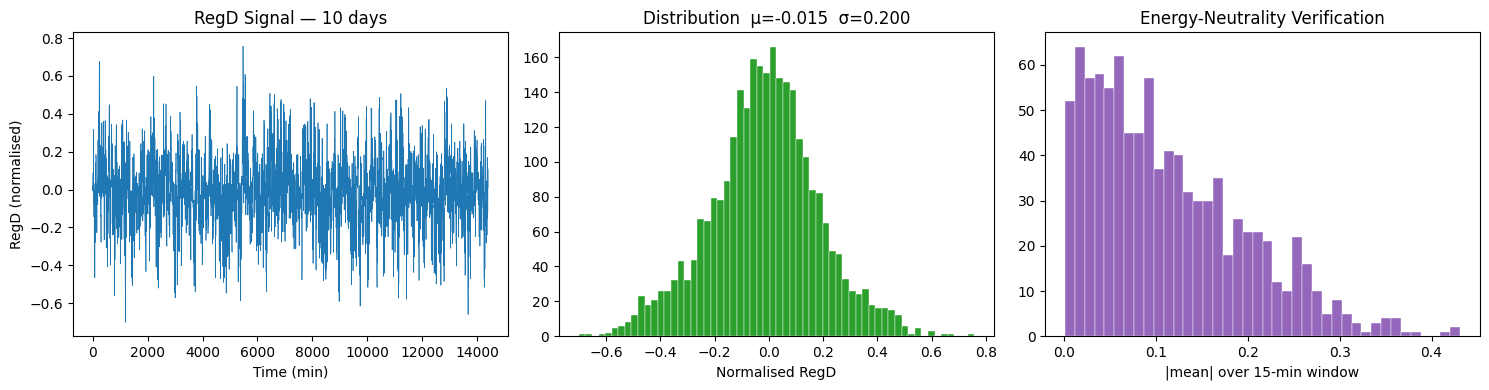

In [4]:
# Sample 2880 ticks (10 days)
gs2 = MacroGridSignal("data/processed/energy", zone="NYC", dt_seconds=300, committed_mw=20.0, seed=0)
gs2.reset()
regd_vals = []
for _ in range(2880):
    regd_vals.append(gs2.step()["regd_signal"])
regd = np.array(regd_vals)

# 15-min window energy neutrality (window=3 ticks)
window_means = [abs(regd[i:i+3].mean()) for i in range(0, len(regd)-3, 3)]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(np.arange(len(regd))*5, regd, lw=0.5); axes[0].set_xlabel("Time (min)")
axes[0].set_ylabel("RegD (normalised)"); axes[0].set_title("RegD Signal — 10 days")

axes[1].hist(regd, bins=60, color="tab:green", edgecolor="white",lw=0.3)
axes[1].set_xlabel("Normalised RegD"); axes[1].set_title(f"Distribution  μ={regd.mean():.3f}  σ={regd.std():.3f}")

axes[2].hist(window_means, bins=40, color="tab:purple", edgecolor="white",lw=0.3)
axes[2].set_xlabel("|mean| over 15-min window"); axes[2].set_title("Energy-Neutrality Verification")
print(f"Mean |window_mean| = {np.mean(window_means):.4f}  (→ 0 = energy-neutral)")
plt.tight_layout(); plt.savefig("notebooks/fig_grid_regd.png", dpi=120); plt.show()

## 4.4 RegD Autocorrelation — AR(1) Structure

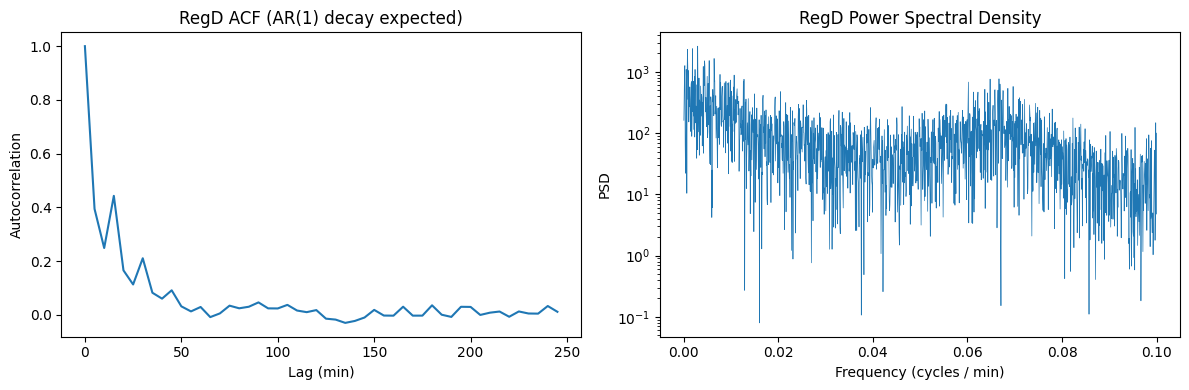

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
# Autocorrelation
from numpy.fft import fft, fftfreq
auto = np.correlate(regd - regd.mean(), regd - regd.mean(), mode='full')
auto = auto[auto.size//2:]; auto /= auto[0]
axes[0].plot(np.arange(50)*5, auto[:50])
axes[0].set_xlabel("Lag (min)"); axes[0].set_ylabel("Autocorrelation")
axes[0].set_title("RegD ACF (AR(1) decay expected)")

# Power spectral density
freqs = fftfreq(len(regd), d=300)   # Hz
psd = np.abs(fft(regd))**2
pos = freqs > 0
axes[1].semilogy(freqs[pos]*60, psd[pos], lw=0.5)
axes[1].set_xlabel("Frequency (cycles / min)"); axes[1].set_ylabel("PSD")
axes[1].set_title("RegD Power Spectral Density")
plt.tight_layout(); plt.savefig("notebooks/fig_grid_acf.png", dpi=120); plt.show()